# ALGO — EMA 50/200 overlay

Loads `prices.txt` (one instrument per column, whitespace-separated, same format as `eval.py`), takes the **ALGO** column, computes the 50- and 200-day exponential moving averages, and overlays them on the price series.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("prices.txt", sep=r"\s+", header=0)
algo = prices["ALGO"]
print(f"{prices.shape[1]} instruments, {prices.shape[0]} days")
algo.head()

51 instruments, 500 days


0    100.00
1     98.49
2     97.83
3     98.02
4     99.13
Name: ALGO, dtype: float64

In [ ]:
ema50 = algo.ewm(span=50, adjust=False).mean()
ema200 = algo.ewm(span=150, adjust=False).mean()

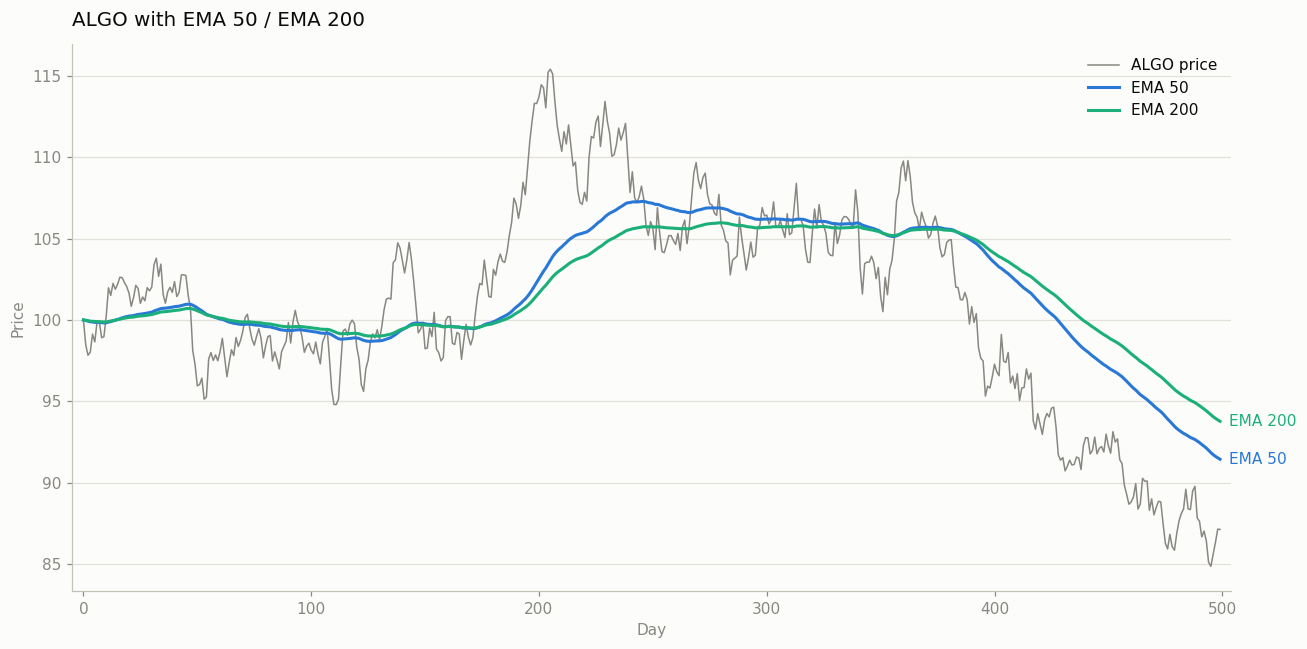

In [6]:
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SERIES_1 = "#2a78d6"  # EMA 50
SERIES_2 = "#1baf7a"  # EMA 200

fig, ax = plt.subplots(figsize=(12, 6), dpi=110, facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(algo.index, algo, color=MUTED, linewidth=1.0, label="ALGO price")
ax.plot(ema50.index, ema50, color=SERIES_1, linewidth=2.0, label="EMA 50")
ax.plot(ema200.index, ema200, color=SERIES_2, linewidth=2.0, label="EMA 200")

# direct labels at the right edge, in each series' color
last = len(algo) - 1
for series, color, name in [(ema50, SERIES_1, "EMA 50"), (ema200, SERIES_2, "EMA 200")]:
    ax.annotate(name, xy=(last, series.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", color=color, fontsize=10)

ax.set_title("ALGO with EMA 50 / EMA 200", color=INK, fontsize=13, loc="left", pad=12)
ax.set_xlabel("Day", color=MUTED)
ax.set_ylabel("Price", color=MUTED)

ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(BASELINE)
ax.tick_params(colors=MUTED)
ax.margins(x=0.01)

ax.legend(loc="upper right", frameon=False, labelcolor=INK)

plt.tight_layout()
plt.show()

## Crossovers

Days where EMA 50 crosses EMA 200 (golden cross = upward, death cross = downward).

In [4]:
diff = ema50 - ema200
sign_change = (diff.shift(1) * diff) < 0
crossings = pd.DataFrame({
    "day": diff.index[sign_change],
    "direction": ["golden cross (50 above 200)" if d > 0 else "death cross (50 below 200)"
                  for d in diff[sign_change]],
    "price": algo[sign_change].round(2),
}).reset_index(drop=True)
crossings

,day,direction,price
0,14,golden cross (50 above 200),101.89
1,54,death cross (50 below 200),95.26
2,139,golden cross (50 above 200),104.43
3,167,death cross (50 below 200),98.74
4,173,golden cross (50 above 200),101.48
5,348,death cross (50 below 200),102.54
6,361,golden cross (50 above 200),108.56
7,384,death cross (50 below 200),101.99


## Donchian channel (20-day)

Upper band = highest high of the past 20 days, lower band = lowest low of the past 20 days, middle band = (upper + lower) / 2. `prices.txt` has a single price per day (no OHLC), so the rolling max/min of the price series stand in for highest high / lowest low.

In [5]:
WINDOW = 20

don_upper = algo.rolling(WINDOW).max()
don_lower = algo.rolling(WINDOW).min()
don_middle = (don_upper + don_lower) / 2

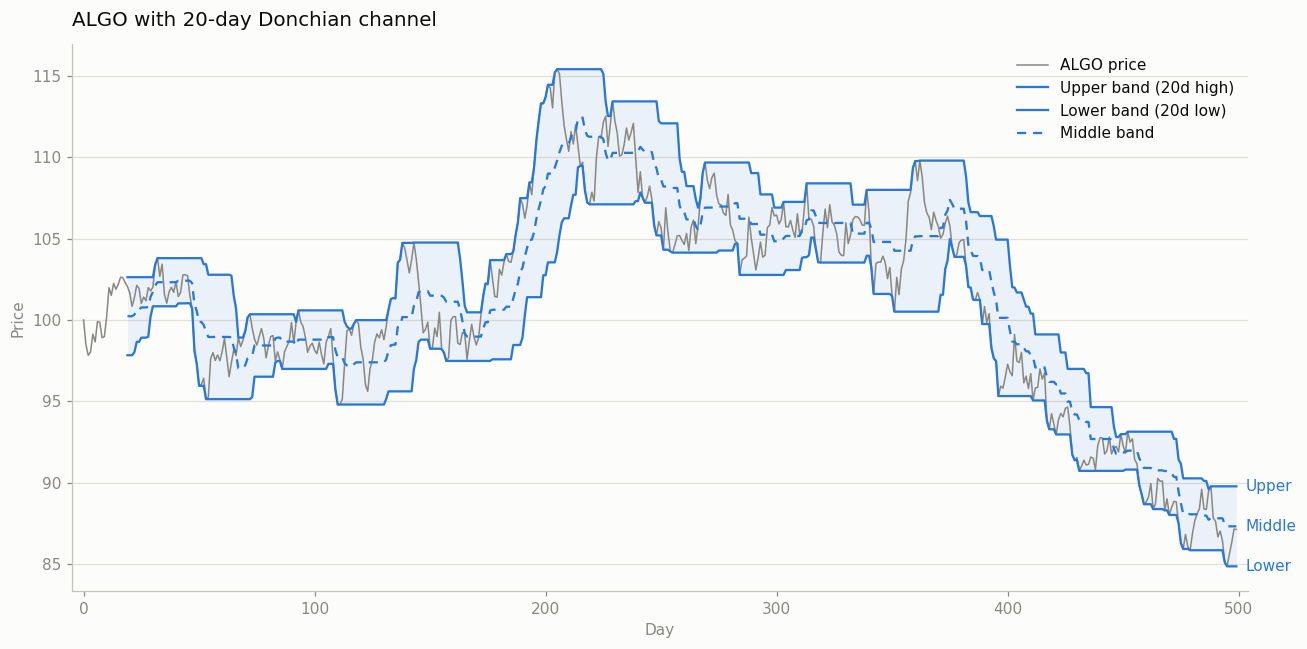

In [6]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=110, facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(algo.index, algo, color=MUTED, linewidth=1.0, label="ALGO price")

# the channel is one entity: one hue, middle band distinguished by dash
ax.fill_between(algo.index, don_lower, don_upper, color=SERIES_1, alpha=0.08, linewidth=0)
ax.plot(don_upper.index, don_upper, color=SERIES_1, linewidth=1.5, label="Upper band (20d high)")
ax.plot(don_lower.index, don_lower, color=SERIES_1, linewidth=1.5, label="Lower band (20d low)")
ax.plot(don_middle.index, don_middle, color=SERIES_1, linewidth=1.5, linestyle=(0, (4, 3)),
        label="Middle band")

# direct labels at the right edge
last = len(algo) - 1
for series, name in [(don_upper, "Upper"), (don_middle, "Middle"), (don_lower, "Lower")]:
    ax.annotate(name, xy=(last, series.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", color=SERIES_1, fontsize=10)

ax.set_title(f"ALGO with {WINDOW}-day Donchian channel", color=INK, fontsize=13, loc="left", pad=12)
ax.set_xlabel("Day", color=MUTED)
ax.set_ylabel("Price", color=MUTED)

ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(BASELINE)
ax.tick_params(colors=MUTED)
ax.margins(x=0.01)

ax.legend(loc="upper right", frameon=False, labelcolor=INK)

plt.tight_layout()
plt.show()